# ARIMA BEST & Random Forest

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## 2. Chargement des données
Lecture du fichier CSV contenant les relevés piézométriques du piézomètre Bourdet.

In [2]:
df = pd.read_csv(
    "data/piezo_saint_fraigne_clean.csv",
    parse_dates=["date_mesure"]
)
df.head()

,date_mesure,niveau_nappe_eau
0,2002-08-01,76.58
1,2002-08-02,76.59
2,2002-08-03,76.59
3,2002-08-04,76.59
4,2002-08-05,76.59


### Mise en forme de l'index
Conversion de la colonne `date_mesure` en index temporel de type `DatetimeIndex`.

> **Pourquoi ?** Les méthodes de séries temporelles comme `resample()` nécessitent
> un index de type `DatetimeIndex`. En définissant la date comme index, on peut
> ensuite rééchantillonner, découper et aligner les données par date facilement.

In [3]:
# Vérifie que la colonne date_mesure est bien présente (pas encore en index)
if 'date_mesure' in df.columns:
    df.set_index('date_mesure', inplace=True)

# S'assure que l'index est bien de type DatetimeIndex
df.index = pd.to_datetime(df.index)

df.head()

,niveau_nappe_eau
date_mesure,
2002-08-01,76.58
2002-08-02,76.59
2002-08-03,76.59
2002-08-04,76.59
2002-08-05,76.59


### Rééchantillonnage mensuel & découpage Train/Test

Les données brutes sont journalières. On les agrège à la **maille mensuelle** (moyenne) pour :
- Réduire le bruit quotidien
- Aligner avec les modèles hydrologiques saisonniers

Le **split Train/Test** isole les **12 derniers mois** (juin 2025 → mai 2026) comme jeu de validation.
Le modèle ne voit jamais ces données pendant l'entraînement — c'est ce qui garantit une évaluation honnête.

In [4]:
# Rééchantillonnage mensuel : on calcule la moyenne du niveau par mois
# 'ME' = Month End (anciennement 'M', déprécié depuis pandas 2.2)
y_mensuel = df["niveau_nappe_eau"].resample('ME').mean()

# ==========================================
# TRAIN / TEST SPLIT — Derniers 12 mois en Test
# ==========================================
# Le dataset s'arrête le 2026-05-31.
# Test : Juin 2025 → Mai 2026 (12 mois)
#train = y_mensuel.loc[:'2025-05-31']
#test  = y_mensuel.loc['2025-06-01':'2026-05-31']

train = y_mensuel.loc[:'2026-02-28']
test  = y_mensuel.loc['2026-03-01':'2026-05-31']

print(f"Train : {len(train)} mois | Test : {len(test)} mois")

Train : 283 mois | Test : 3 mois


In [5]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [6]:
!pip install pmdarima

## 3. Modèle SARIMAX (ARIMA Saisonnier)

**SARIMAX** = Seasonal AutoRegressive Integrated Moving Average with eXogenous variables.

Les paramètres `order=(p, d, q)` contrôlent :
- `p=1` : 1 terme autorégressif (la valeur du mois précédent influence le présent)
- `d=1` : 1 différenciation pour rendre la série stationnaire
- `q=1` : 1 terme de moyenne mobile (correction de l'erreur passée)

Les paramètres `seasonal_order=(P, D, Q, m)` avec `m=12` capturent la **saisonnalité annuelle** :
le niveau de la nappe en juin 2025 est corrélé au niveau de juin 2024, juin 2023, etc.

In [7]:
# Un ARIMA(1, 1, 1) avec saisonnalité différenciée (1, 1, 0, 12)
model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 0, 12))
arima_fitted = model.fit()

forecast = arima_fitted.predict(start=test.index[0], end=test.index[-1])

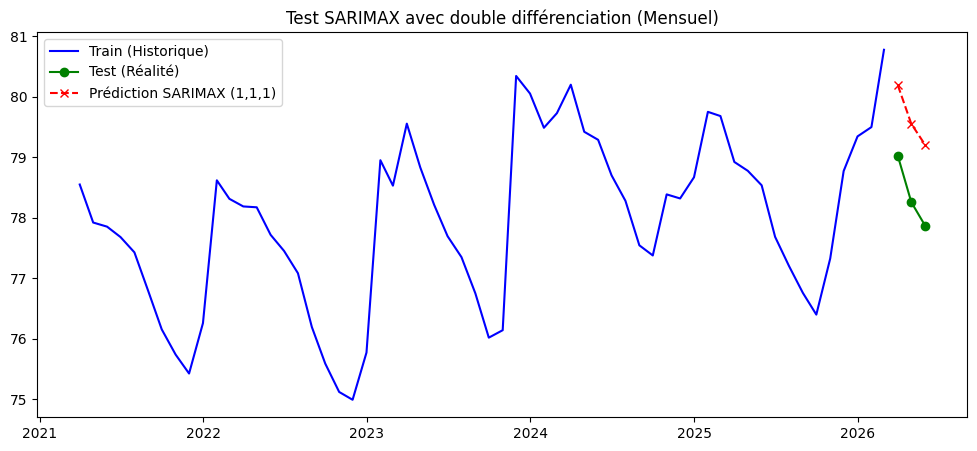

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(train.tail(60), label='Train (Historique)', color='blue')
plt.plot(test, label='Test (Réalité)', color='green', marker='o')
plt.plot(forecast, label='Prédiction SARIMAX (1,1,1)', color='red', linestyle='--', marker='x')
plt.legend()
plt.title("Test SARIMAX avec double différenciation (Mensuel)")
plt.show()

## 4. Random Forest — Feature Engineering

Le **Random Forest** n'est pas un modèle de séries temporelles natif : il ne comprend pas
la notion de temps. On lui fournit donc des **features de lag** (décalages temporels) :

| Feature | Signification |
|---|---|
| `lag_1` | Niveau du mois précédent |
| `lag_2` | Niveau il y a 2 mois |
| `lag_3` | Niveau il y a 3 mois |
| `lag_12` | Niveau il y a 12 mois (même saison l'an dernier) |
| `mois` | Numéro du mois (saisonnalité) |
| `moyenne_3m` | Tendance récente sur 3 mois |
| `moyenne_6m` | Tendance moyen terme sur 6 mois |

On transforme ainsi un problème temporel en problème de **régression supervisée classique**.

In [9]:
# 1. Préparation des colonnes (Lag)
df_ml = pd.DataFrame(y_mensuel)
df_ml['mois'] = df_ml.index.month
df_ml['lag_1'] = df_ml['niveau_nappe_eau'].shift(1)
df_ml['lag_2'] = df_ml['niveau_nappe_eau'].shift(2)
df_ml['lag_3'] = df_ml['niveau_nappe_eau'].shift(3)
df_ml['lag_12'] = df_ml['niveau_nappe_eau'].shift(12)
df_ml = df_ml.dropna()

# 2. Split
X = df_ml[['mois', 'lag_1', 'lag_2', 'lag_3']]
y_target = df_ml['niveau_nappe_eau']

#X_train, X_test = X.loc[:'2025-05-31'], X.loc['2025-06-01':]
#y_train, y_test = y_target.loc[:'2025-05-31'], y_target.loc['2025-06-01':]

X_train, X_test = X.loc[:'2026-02-28'], X.loc['2026-03-01':'2026-05-31']
y_train, y_test = y_target.loc[:'2026-02-28'], y_target.loc['2026-03-01':'2026-05-31']

# 3. Fit & Predict
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

forecast_rf = pd.Series(rf.predict(X_test), index=test.index)

In [10]:
df_ml.head()

,niveau_nappe_eau,mois,lag_1,lag_2,lag_3,lag_12
date_mesure,,,,,,
2003-08-31,76.364516,8,77.200968,77.769333,78.140968,76.582258
2003-09-30,75.825000,9,76.364516,77.200968,77.769333,76.601333
2003-10-31,75.542581,10,75.825000,76.364516,77.200968,76.225806
2003-11-30,76.553333,11,75.542581,75.825000,76.364516,78.374667
2003-12-31,78.765806,12,76.553333,75.542581,75.825000,79.355484


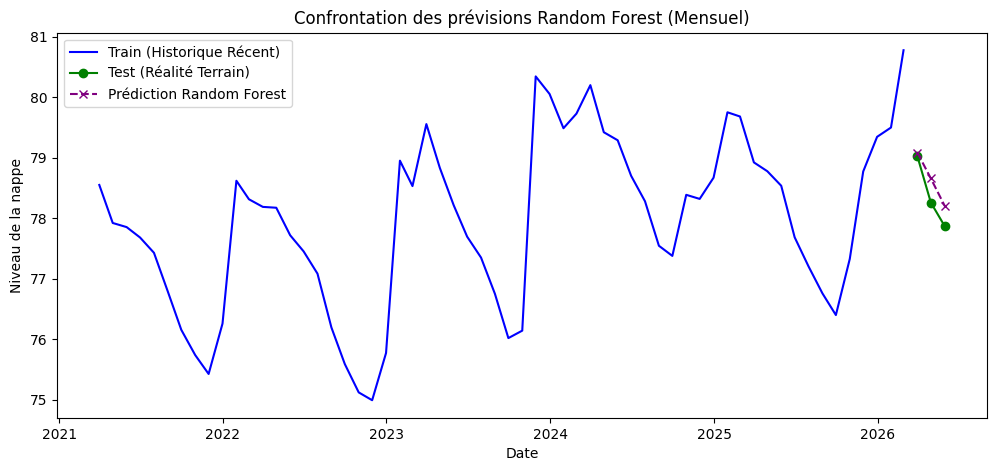

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# On affiche les 3 dernières années d'historique (36 mois) pour voir le raccord
plt.plot(y_train.tail(60), label='Train (Historique Récent)', color='blue')

# On affiche la vraie réalité du terrain (le test)
plt.plot(y_test, label='Test (Réalité Terrain)', color='green', marker='o')

# On affiche la prédiction de l'algorithme Random Forest
plt.plot(forecast_rf, label='Prédiction Random Forest', color='purple', linestyle='--', marker='x')

plt.title("Confrontation des prévisions Random Forest (Mensuel)")
plt.xlabel("Date")
plt.ylabel("Niveau de la nappe")
plt.legend()
plt.show()

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# 1. On définit la grille des paramètres que l'on veut tester
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 0.8, 1.0]
}

# 2. On instancie un Random Forest de base
rf_base = RandomForestRegressor(random_state=42)

# 3. On configure la recherche automatique (GridSearch)
# cv=5 fait une validation croisée pour être sûr de la robustesse
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# 4. On lance la recherche sur les données d'entraînement
grid_search.fit(X_train, y_train)

# 5. On affiche les meilleurs paramètres trouvés !
print("Meilleurs paramètres trouvés :")
print(grid_search.best_params_)

Meilleurs paramètres trouvés :
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}


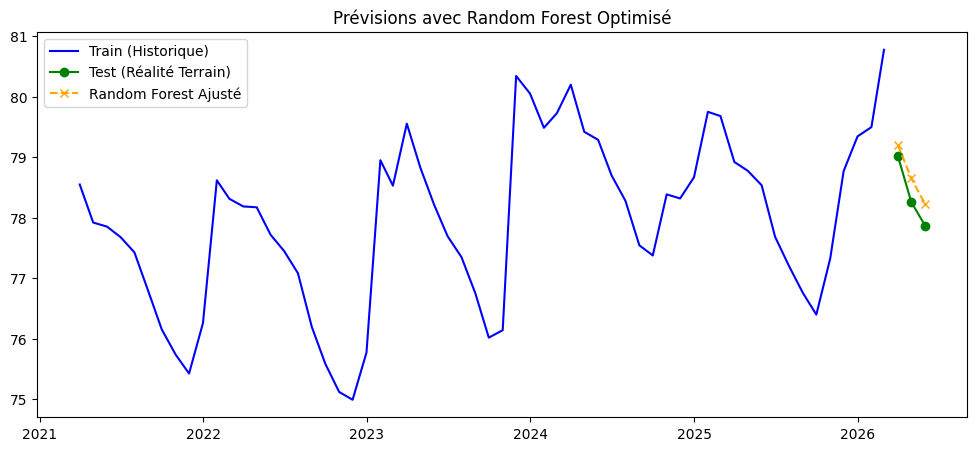

In [13]:
# 1. On récupère le modèle optimisé
best_rf = grid_search.best_estimator_

# 2. On refait la prédiction
predictions_optimise = best_rf.predict(X_test)
forecast_rf_opt = pd.Series(predictions_optimise, index=y_test.index)

# 3. On l'affiche sur le graphique
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_train.tail(60), label='Train (Historique)', color='blue')
plt.plot(y_test, label='Test (Réalité Terrain)', color='green', marker='o')
plt.plot(forecast_rf_opt, label='Random Forest Ajusté', color='orange', linestyle='--', marker='x')

plt.title("Prévisions avec Random Forest Optimisé")
plt.legend()

plt.show()

In [14]:
# Moyenne du niveau de la nappe sur les 3 derniers mois (tendance récente)
df_ml['moyenne_3m'] = df_ml['niveau_nappe_eau'].rolling(window=3).mean()

# Moyenne du niveau sur les 6 derniers mois (tendance moyen terme)
df_ml['moyenne_6m'] = df_ml['niveau_nappe_eau'].rolling(window=6).mean()

# IMPORTANT : Applique le .dropna() APRÈS avoir créé ces nouvelles variables
df_ml = df_ml.dropna()
# Sélection des variables d'entrée (Features)
#X = df_ml[['mois', 'lag_1', 'lag_2', 'lag_3', 'lag_12']]
# Si tu as ajouté les moyennes mobiles, mets :
X = df_ml[['mois', 'lag_1', 'lag_2', 'lag_3', 'lag_12', 'moyenne_3m', 'moyenne_6m']]

y_target = df_ml['niveau_nappe_eau']

# Split Train / Test
#X_train, X_test = X.loc[:'2025-05-31'], X.loc['2025-06-01':'2026-05-31']
#y_train, y_test = y_target.loc[:'2025-05-31'], y_target.loc['2025-06-01':'2026-05-31']
X_train, X_test = X.loc[:'2026-02-28'], X.loc['2026-03-01':'2026-05-31']
y_train, y_test = y_target.loc[:'2026-02-28'], y_target.loc['2026-03-01':'2026-05-31']

In [22]:
X_train

,mois,lag_1,lag_2,lag_3,lag_12,moyenne_3m,moyenne_6m
date_mesure,,,,,,,
2004-01-31,1,78.765806,76.553333,75.542581,79.776452,78.461649,77.186174
2004-02-29,2,80.065806,78.765806,76.553333,79.265714,79.258124,77.615881
2004-03-31,3,78.942759,80.065806,78.765806,78.845790,79.204791,78.079349
2004-04-30,4,78.605806,78.942759,80.065806,78.113183,78.744744,78.603196
2004-05-31,5,78.685667,78.605806,78.942759,78.140968,78.579416,78.918770
...,...,...,...,...,...,...,...
2025-10-31,10,76.400667,76.759032,77.204194,78.388065,76.829254,77.319337
2025-11-30,11,77.328065,76.400667,76.759032,78.320667,77.500910,77.358659
2025-12-31,12,78.774000,77.328065,76.400667,78.671290,78.482946,77.635455


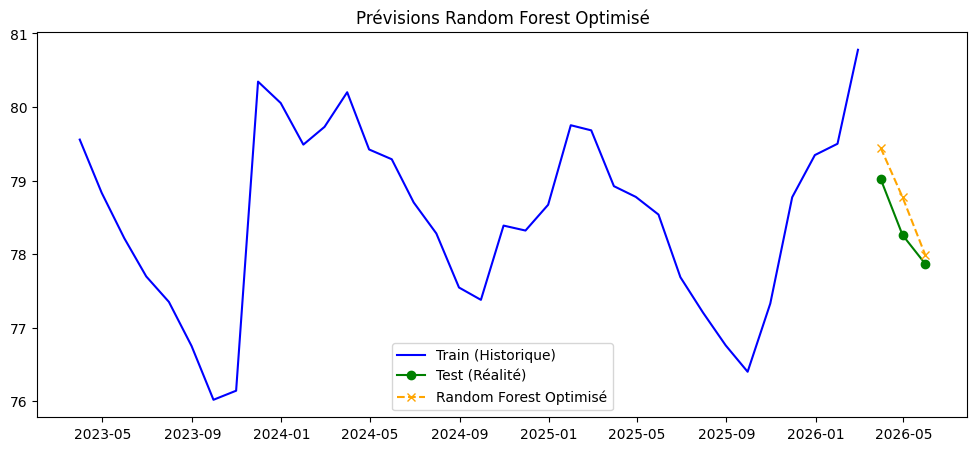

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# 1. Grille de paramètres à tester
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# 2. Lancement de la recherche (ça peut prendre 10-20 secondes)
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 3. Prédiction avec le meilleur modèle trouvé
best_rf = grid_search.best_estimator_
forecast_opt = pd.Series(best_rf.predict(X_test), index=y_test.index)

# 4. Graphique
plt.figure(figsize=(12, 5))
plt.plot(y_train.tail(36), label='Train (Historique)', color='blue')
plt.plot(y_test, label='Test (Réalité)', color='green', marker='o')
plt.plot(forecast_opt, label='Random Forest Optimisé', color='orange', linestyle='--', marker='x')
plt.title("Prévisions Random Forest Optimisé")
plt.legend()
plt.show()

In [16]:
!pip install xgboost

## 5. XGBoost — Gradient Boosting

**XGBoost** est un algorithme de *gradient boosting* : il construit des arbres de décision
en séquence, chaque arbre corrigeant les erreurs du précédent.

Il surpasse souvent le Random Forest sur les séries temporelles car il est plus sensible
aux **relations non-linéaires** et aux **interactions entre features**.

La grille de paramètres testés :
- `n_estimators` : nombre d'arbres
- `learning_rate` : vitesse d'apprentissage (trop élevé = overfitting)
- `max_depth` : profondeur max de chaque arbre
- `subsample` / `colsample_bytree` : régularisation par sous-échantillonnage

In [17]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd

# 1. On définit la grille des paramètres à tester
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.8, 1.0]
}

# 2. Instanciation du modèle de base
xgb_base = XGBRegressor(random_state=42)

# 3. Configuration de la recherche automatique (avec 3 découpages de validation)
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 4. Entraînement sur tes données (X_train et y_train avec les Lags)
grid_search_xgb.fit(X_train, y_train)

# 5. Affichage des meilleurs réglages trouvés
print("Meilleurs paramètres XGBoost :", grid_search_xgb.best_params_)

Meilleurs paramètres XGBoost : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.7}


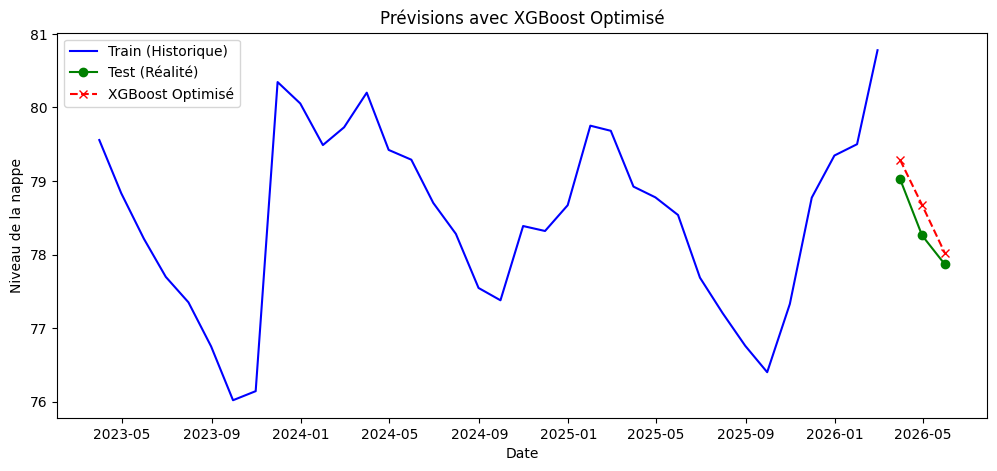

In [18]:
# 1. Récupération du meilleur modèle
best_xgb = grid_search_xgb.best_estimator_

# 2. Prédiction sur l'année de test
forecast_xgb_opt = pd.Series(best_xgb.predict(X_test), index=y_test.index)

# 3. Graphique de comparaison
plt.figure(figsize=(12, 5))
plt.plot(y_train.tail(36), label='Train (Historique)', color='blue')
plt.plot(y_test, label='Test (Réalité)', color='green', marker='o')
plt.plot(forecast_xgb_opt, label='XGBoost Optimisé', color='red', linestyle='--', marker='x')

plt.title("Prévisions avec XGBoost Optimisé")
plt.xlabel("Date")
plt.ylabel("Niveau de la nappe")
plt.legend()
plt.show()

In [19]:
!pip install prophet

## 6. Prophet — Optimisation des hyperparamètres

**Prophet** (Meta) est conçu pour les séries temporelles avec **saisonnalités fortes et tendances**.
Il décompose la série en : `y(t) = tendance + saisonnalité + bruit`.

Les hyperparamètres clés :
- `changepoint_prior_scale` : flexibilité de la tendance (fort = suit mieux les ruptures)
- `seasonality_prior_scale` : amplitude de la saisonnalité autorisée
- `seasonality_mode` : `additive` (saisons de même amplitude) vs `multiplicative` (saisons proportionnelles)

On effectue un **grid search manuel** sur 3 mois de validation (mars–mai 2026) pour trouver
la combinaison minimisant le RMSE.

In [20]:
import itertools
from prophet import Prophet
import pandas as pd
import numpy as np

# 1. Formatage des données pour Prophet
df_prophet = y_mensuel.reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = df_prophet['ds'].dt.tz_localize(None)

# Split sur les 3 derniers mois (Mars, Avril, Mai 2026)
train_p = df_prophet[df_prophet['ds'] <= '2026-02-28']
test_p = df_prophet[df_prophet['ds'] >= '2026-03-01']

# 2. Définition de la grille de paramètres à tester
param_grid = {
    'changepoint_prior_scale': [0.001, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

# Générer toutes les combinaisons possibles
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []

# 3. Boucle d'optimisation (Recherche de la plus petite erreur)
for params in all_params:
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, **params)
    m.fit(train_p)

    # Prédire les 3 mois de test
    future = m.make_future_dataframe(periods=3, freq='ME')
    forecast = m.predict(future)
    predictions = forecast['yhat'].iloc[-3:].values

    # Calcul de l'erreur (RMSE) par rapport à la réalité
    rmse = np.sqrt(np.mean((test_p['y'].values - predictions) ** 2))
    rmses.append(rmse)

# Trouver les meilleurs paramètres
best_params = all_params[np.argmin(rmses)]
print("Meilleurs paramètres trouvés pour Prophet :", best_params)

20:10:39 - cmdstanpy - INFO - Chain [1] start processing
20:10:39 - cmdstanpy - INFO - Chain [1] done processing
20:10:39 - cmdstanpy - INFO - Chain [1] start processing
20:10:39 - cmdstanpy - INFO - Chain [1] done processing
20:10:39 - cmdstanpy - INFO - Chain [1] start processing
20:10:39 - cmdstanpy - INFO - Chain [1] done processing
20:10:40 - cmdstanpy - INFO - Chain [1] start processing
20:10:40 - cmdstanpy - INFO - Chain [1] done processing
20:10:40 - cmdstanpy - INFO - Chain [1] start processing
20:10:40 - cmdstanpy - INFO - Chain [1] done processing
20:10:40 - cmdstanpy - INFO - Chain [1] start processing
20:10:40 - cmdstanpy - INFO - Chain [1] done processing
20:10:40 - cmdstanpy - INFO - Chain [1] start processing
20:10:40 - cmdstanpy - INFO - Chain [1] done processing
20:10:40 - cmdstanpy - INFO - Chain [1] start processing
20:10:40 - cmdstanpy - INFO - Chain [1] done processing
20:10:40 - cmdstanpy - INFO - Chain [1] start processing
20:10:40 - cmdstanpy - INFO - Chain [1]

Meilleurs paramètres trouvés pour Prophet : {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}


20:10:42 - cmdstanpy - INFO - Chain [1] start processing
20:10:42 - cmdstanpy - INFO - Chain [1] done processing


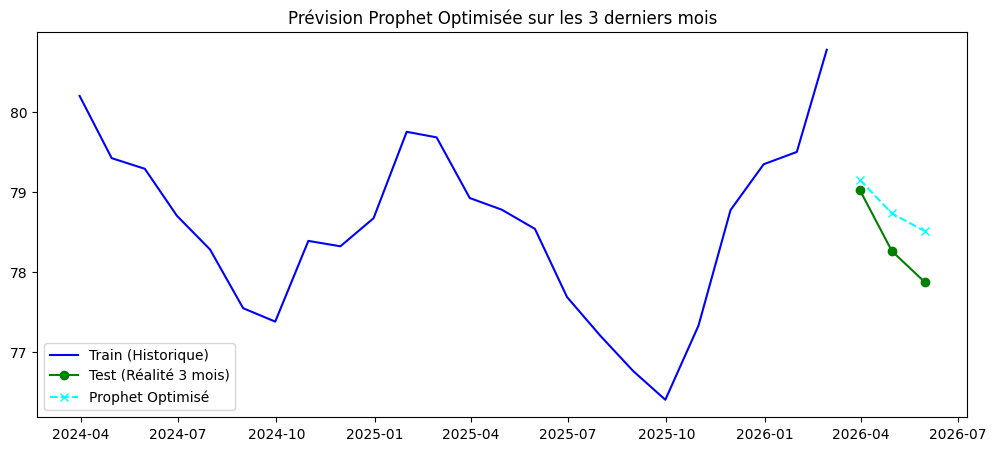

In [21]:
# 1. Entraînement du meilleur modèle
best_m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, **best_params)
best_m.fit(train_p)

# 2. Prédiction à 3 mois
future = best_m.make_future_dataframe(periods=3, freq='ME')
forecast_final = best_m.predict(future)

# 3. Extraction des 3 points de prédiction
forecast_prophet_opt = pd.Series(forecast_final['yhat'].iloc[-3:].values, index=pd.to_datetime(test_p['ds'].values))

# 4. Graphique zoomé sur la fin pour bien voir les 3 mois
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
# On affiche les 2 dernières années pour bien voir l'historique récent
plt.plot(train.tail(24), label='Train (Historique)', color='blue')
plt.plot(test, label='Test (Réalité 3 mois)', color='green', marker='o')
plt.plot(forecast_prophet_opt, label='Prophet Optimisé', color='cyan', linestyle='--', marker='x')

plt.title("Prévision Prophet Optimisée sur les 3 derniers mois")
plt.legend()
plt.show()